In [1]:
from langchain_ollama import ChatOllama

model = ChatOllama(
    model="gpt-oss",
    temperature=0
)

d:\workspace\AI\langchain-academy\langgraph-foundation\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


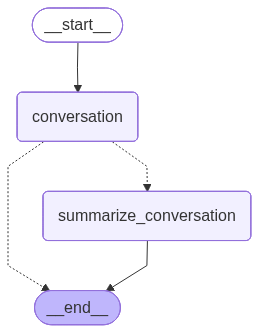

In [6]:
from IPython.display import Image, display
from typing import Literal

from langchain_core.messages import SystemMessage, HumanMessage, RemoveMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState

class State(MessagesState):
    summary: str

def call_model(state: State):
    summary = state.get("summart", "")
    if summary:
        system_message = f"Summary of conversation earlier: {summary}"
        messages = [SystemMessage(content=system_message)] + state["messages"]
    else:
        messages = state["messages"]
    
    response = model.invoke(messages)
    return {"messages": response}

def summarize_conversation(state: State):
    summary = state.get("summary", "")
    if summary:
        summary_message = (
            f"This is summary of the conversation to date: {summary}\n\n"
            "Extend the summary by taking into account the new messages above:"
        )
    else:
        summary_message = "Create a summary of the conversation above:"
    
    messages = state["messages"] + [HumanMessage(content=summary_message)]
    response = model.invoke(messages)

    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"summary": response.content, "messages": delete_messages}

def should_continue(state:State) -> Literal["summarize_conversation",END]:
    messages = state["messages"]
    if len(messages)>6:
        return "summarize_conversation"
    return END

# Define a new graph
workflow = StateGraph(State)
workflow.add_node("conversation", call_model)
workflow.add_node(summarize_conversation)

# Set the entrypoint as conversation
workflow.add_edge(START, "conversation")
workflow.add_conditional_edges("conversation", should_continue)
workflow.add_edge("summarize_conversation", END)

# Compile
memory = MemorySaver()
graph = workflow.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))


Langgraph supports a few different streaming modes for graph state:
- `values`: This streams the full state of the graph after each node is called.
- `updates`: This streams updates to the state of the graph after each node is called.

![values_vs_updates.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbaf892d24625a201744e5_streaming1.png)

Let's look at `stream_mode="updates"`.

Because we stream with `updates`, we only see updates to the state after node in the graph is run.

Each `chunk` is a dict with `node_name` as the key and the updated state as the value.

In [8]:
config = {"configurable": {"thread_id": "1"}}

for chunk in graph.stream({"messages": HumanMessage(content="Hi I am Najeeb, What do you know about me from your training data.")}, config, stream_mode="updates"):
    print(chunk)

{'conversation': {'messages': AIMessage(content='I don’t have any personal data about you—unless you share something yourself. I don’t have the ability to look up or remember private details about individual users. If there’s something specific you’d like to discuss or if you want me to help with a topic, feel free to let me know!', additional_kwargs={}, response_metadata={'model': 'gpt-oss', 'created_at': '2026-04-20T15:02:05.2389181Z', 'done': True, 'done_reason': 'stop', 'total_duration': 5905676200, 'load_duration': 4537536300, 'prompt_eval_count': 103, 'prompt_eval_duration': 76689900, 'eval_count': 175, 'eval_duration': 1128293800, 'logprobs': None, 'model_name': 'gpt-oss', 'model_provider': 'ollama'}, id='lc_run--019dab69-9fa5-79b0-a4a9-dd7cbc2a448d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 103, 'output_tokens': 175, 'total_tokens': 278})}}


In [9]:
for chunk in graph.stream({"messages": [HumanMessage(content="I love programming and mainly use Java and Python")]}, config, stream_mode="updates"):
    chunk["conversation"]["messages"].pretty_print()

================================== Ai Message ==================================

That’s a solid combo! Java and Python cover a huge swath of the development landscape—from enterprise back‑ends and Android apps to data science, automation, and web services.

### Quick sanity‑check: What do you want to do next?

| Domain | Typical tech stack | Why it pairs well with Java/Python |
|--------|-------------------|-----------------------------------|
| **Enterprise Back‑End** | Spring Boot (Java) + Micronaut/Quarkus + FastAPI (Python) | High throughput, strong typing, easy micro‑service glue |
| **Data Science / ML** | Jupyter / Pandas / scikit‑learn (Python) + Java for production pipelines (Spark, Flink) | Python’s rich ecosystem + Java’s performance for large‑scale processing |
| **Mobile** | Android (Java/Kotlin) + Kivy / BeeWare (Python) | Native Android + cross‑platform Python UI |
| **Web** | Spring MVC / Jakarta EE (Java) + Django / Flask (Python) | MVC patterns, ORM, RESTful APIs |
|

In [10]:
# Start conversation, again
config = {"configurable": {"thread_id": "2"}}

input_message = HumanMessage(content="hi! I'm Najeeb")

for event in graph.stream({"messages": [input_message]}, config, stream_mode="values"):
    for m in event["messages"]:
        m.pretty_print()
    print("---"*25)

================================ Human Message =================================

hi! I'm Najeeb
---------------------------------------------------------------------------
================================ Human Message =================================

hi! I'm Najeeb
================================== Ai Message ==================================

Hey Najeeb! 👋 How’s it going? What’s on your mind today?
---------------------------------------------------------------------------


# Streaming Tokens

We often want to stream more than graph state.

In particular, with chat model calls it is common to stream the tokens as they are generated.

We can do this [using the `.astream_events` method](https://docs.langchain.com/oss/python/langchain/models#advanced-streaming-topics:streaming-events), which streams back events as they happen inside nodes!

Each event is a dict with a few keys:
 
* `event`: This is the type of event that is being emitted. 
* `name`: This is the name of event.
* `data`: This is the data associated with the event.
* `metadata`: Contains`langgraph_node`, the node emitting the event.


In [11]:
config = {"configurable": {"thread_id": "3"}}
input_message = HumanMessage(content="Tell me about the Python Programming.")

async for event in graph.astream_events({"messages": [input_message]}, config, version="v2"):
    print(f"Node: {event["metadata"].get("langgraph_node", "")}. Type: {event["event"]}. Name: {event["name"]}")

Node: . Type: on_chain_start. Name: LangGraph
Node: conversation. Type: on_chain_start. Name: conversation
Node: conversation. Type: on_chat_model_start. Name: ChatOllama
Node: conversation. Type: on_chat_model_stream. Name: ChatOllama
Node: conversation. Type: on_chat_model_stream. Name: ChatOllama
Node: conversation. Type: on_chat_model_stream. Name: ChatOllama
Node: conversation. Type: on_chat_model_stream. Name: ChatOllama
Node: conversation. Type: on_chat_model_stream. Name: ChatOllama
Node: conversation. Type: on_chat_model_stream. Name: ChatOllama
Node: conversation. Type: on_chat_model_stream. Name: ChatOllama
Node: conversation. Type: on_chat_model_stream. Name: ChatOllama
Node: conversation. Type: on_chat_model_stream. Name: ChatOllama
Node: conversation. Type: on_chat_model_stream. Name: ChatOllama
Node: conversation. Type: on_chat_model_stream. Name: ChatOllama
Node: conversation. Type: on_chat_model_stream. Name: ChatOllama
Node: conversation. Type: on_chat_model_stream. N

The central point is that tokens from chat models within your graph have the `on_chat_model_stream` type.

We can use `event['metadata']['langgraph_node']` to select the node to stream from.

And we can use `event['data']` to get the actual data for each event, which in this case is an `AIMessageChunk`. 

In [14]:
node_to_stream = "conversation"

config = {"configurable": {"thread_id": "4"}}

input_message = HumanMessage(content="Tell me about the Python Programming best practices for production grade AGentic AI Applications")

async for event in graph.astream_events({"messages":[input_message]}, config, version="v2"):
    if event["event"] == "on_chat_model_stream" and event["metadata"].get("langgraph_node", "") == node_to_stream:
        print(event["data"])

{'chunk': AIMessageChunk(content='', additional_kwargs={}, response_metadata={}, id='lc_run--019dab78-593b-75e1-9545-a09854e31a72', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[])}
{'chunk': AIMessageChunk(content='', additional_kwargs={}, response_metadata={}, id='lc_run--019dab78-593b-75e1-9545-a09854e31a72', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[])}
{'chunk': AIMessageChunk(content='', additional_kwargs={}, response_metadata={}, id='lc_run--019dab78-593b-75e1-9545-a09854e31a72', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[])}
{'chunk': AIMessageChunk(content='', additional_kwargs={}, response_metadata={}, id='lc_run--019dab78-593b-75e1-9545-a09854e31a72', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[])}
{'chunk': AIMessageChunk(content='', additional_kwargs={}, response_metadata={}, id='lc_run--019dab78-593b-75e1-9545-a09854e31a72', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[])}
{'chunk': AIMessageChunk(content='', add

In [16]:
config = {"configurable": {"thread_id": "5"}}

async for event in graph.astream_events({"messages":[input_message]}, config, version="v2"):
    if event["event"] == "on_chat_model_stream" and event["metadata"].get("langgraph_node", "") == node_to_stream:
        data = event["data"]
        print(data["chunk"].content, end="|")


|||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||Below| is| a| practical| “|tool|‑|kit|”| of| Python| best|‑|pr|act|ices| that| cover| **|everything|**| you| need| to| move| an| AI|‑|agent| from| a| notebook| into| a| fully|‑|f|ledged

In [17]:
config = {"configurable": {"thread_id": "6"}}

async for event in graph.astream_events({"messages":[input_message]}, config, version="v2"):
    if event["event"] == "on_chat_model_stream" and event["metadata"].get("langgraph_node", "") == node_to_stream:
        data = event["data"]
        print(data["chunk"].content, end="")

# Python Best‑Practice Playbook for Production‑Grade **Agentic AI** Applications  

> “Agentic AI” usually refers to software that behaves like an autonomous agent:  
> – **Stateful** (memory, history, context)  
> – **Decision‑making** (planning, planning, or RL style)  
> – **Multi‑step interactions** (call APIs, call LLMs, read files, etc.)  
> – **Scalable and observable** in a cloud environment  

Below is a living‑document‑style checklist that blends classic Python engineering hygiene with the special demands of a production‑grade autonomous AI system.

---

## 1. Project Structure & Packaging

| Guideline | Why it matters | Typical tools |
|-----------|----------------|---------------|
| **Monorepo or separate repos?** | Keeps dependencies aligned. Monorepo for tightly coupled components; separate repos for independent agents. | Git, GitHub, GitLab |
| **`pyproject.toml` + Poetry** | Declarative, reproducible builds. Avoids `requirements.txt` drift. | Poetry, Hatch |
| **Virtual